# DengAI forest validation dashboard

Run `train_forest_ensemble.py` first. This notebook reads `forest_validation_predictions.csv` and `forest_validation_scores.csv` from its `--output-dir`. Change `ARTIFACT_DIR` below if necessary. Each forecast origin covers a full city-specific test horizon. Historical windows can overlap; use the latest origin for a separate chronological holdout. The selected ensemble was chosen on older origins, so its development score is in-sample for model selection.

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

ARTIFACT_DIR = Path("../artifacts")  # Or an absolute path to --output-dir
PREDICTION = "robust_ensemble_prediction"  # Also: selected_ensemble_prediction
CITY_NAMES = {"sj": "San Juan", "iq": "Iquitos"}

pred_path = ARTIFACT_DIR / "forest_validation_predictions.csv"
score_path = ARTIFACT_DIR / "forest_validation_scores.csv"
if not pred_path.is_file() or not score_path.is_file():
    raise FileNotFoundError(
        f"Run train_forest_ensemble.py first and point ARTIFACT_DIR to its output. "
        f"Missing: {[str(p) for p in (pred_path, score_path) if not p.is_file()]}"
    )
predictions = pd.read_csv(pred_path, parse_dates=["week_start_date"])
scores = pd.read_csv(score_path)
required = {"city", "origin", "week_start_date", "actual",
            "selected_ensemble_prediction", "robust_ensemble_prediction"}
missing = required.difference(predictions.columns)
if missing:
    raise ValueError(f"Missing columns {sorted(missing)}. Rerun the updated training script.")
if PREDICTION not in predictions.columns:
    raise ValueError(f"Unknown prediction column: {PREDICTION}")
print(f"Loaded {len(predictions):,} forecast rows from {pred_path}")
print("Available cities:", ", ".join(sorted(predictions.city.unique())))

Loaded 2,184 forecast rows from ../artifacts/forest_validation_predictions.csv
Available cities: iq, sj


## Check the exported MAE

These values should match the training script's score CSV. Origin numbers are within each city. `all_origins` includes repeated dates where forecast windows overlap, so it is a score over origin–week pairs rather than unique historical weeks.

In [10]:
model_name = {"selected_ensemble_prediction": "selected_forest_ensemble",
              "robust_ensemble_prediction": "robust_forest_ensemble"}[PREDICTION]
rows = []
for city, city_df in predictions.groupby("city"):
    holdout_origin = city_df.origin.max()
    for split, group in (("development", city_df[city_df.origin < holdout_origin]),
                         ("chronological_holdout", city_df[city_df.origin == holdout_origin]),
                         ("all_origins", city_df)):
        if group.empty:
            continue
        calculated = mean_absolute_error(group.actual, group[PREDICTION])
        saved = scores.loc[(scores.city == city) & (scores.split == split)
                           & (scores.model == model_name), "mae"]
        rows.append({"city": city, "split": split, "n": len(group),
                     "calculated_mae": calculated,
                     "saved_mae": saved.iloc[0] if len(saved) == 1 else np.nan})
check = pd.DataFrame(rows)
if not np.allclose(check.calculated_mae, check.saved_mae, equal_nan=False):
    raise AssertionError("Saved scores do not match prediction rows; rerun training.")
display(check.round(3))

,city,split,n,calculated_mae,saved_mae
0,iq,development,468,6.363,6.363
1,iq,chronological_holdout,156,7.019,7.019
2,iq,all_origins,624,6.527,6.527
3,sj,development,1300,39.861,39.861
4,sj,chronological_holdout,260,16.465,16.465
5,sj,all_origins,1560,35.962,35.962


## Chronological holdout

The latest origin for each city was excluded from ensemble selection. Compare the curves to see outbreak timing and prediction amplitude. Residuals are `actual − predicted`; positive values indicate underprediction.

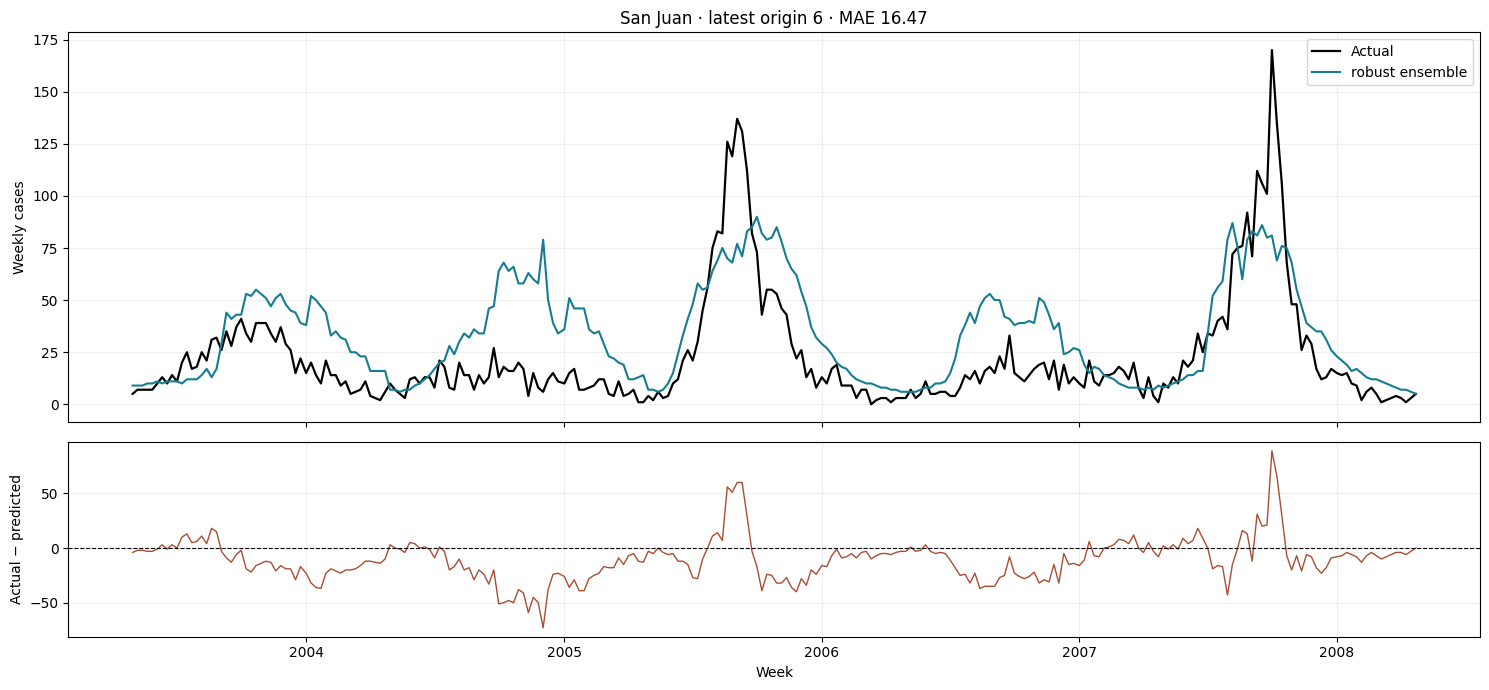

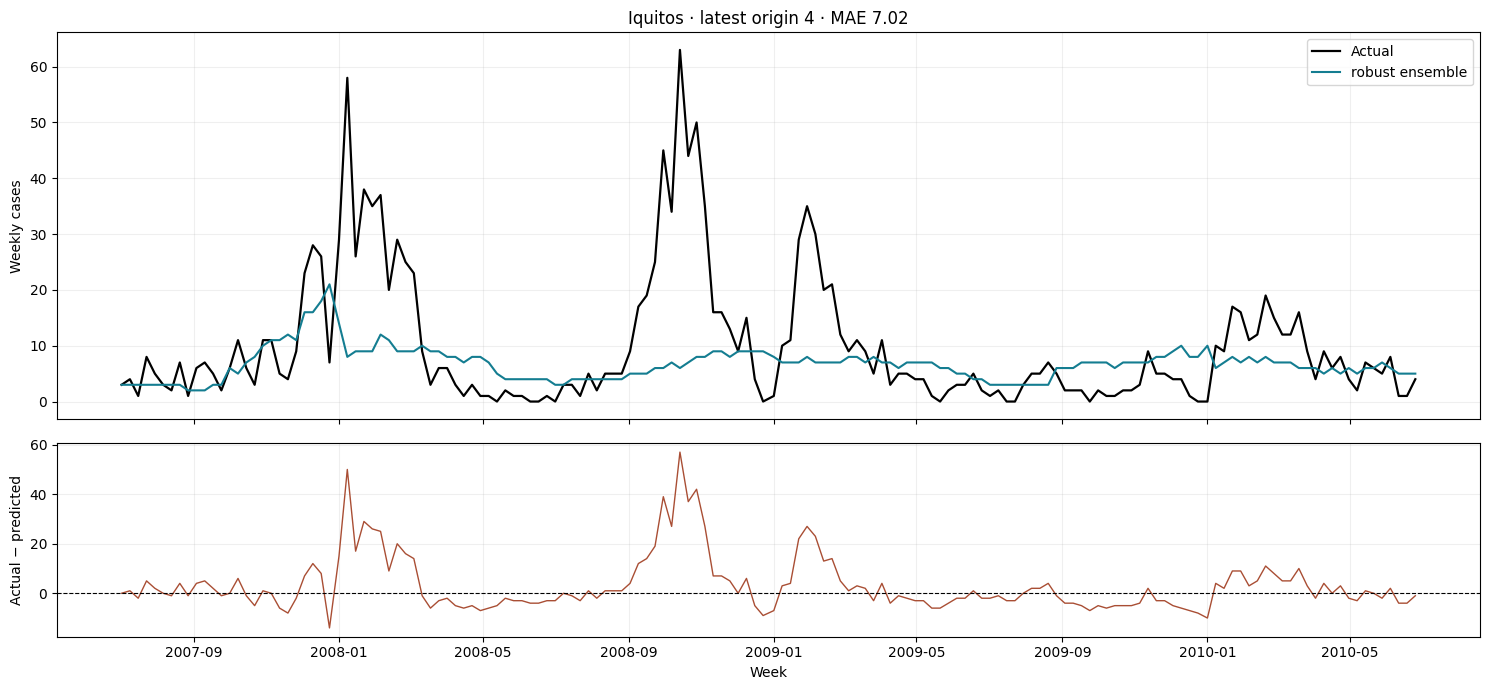

In [11]:
def holdout_for(city):
    frame = predictions.loc[predictions.city.eq(city)].copy()
    if frame.empty:
        raise ValueError(f"No validation rows for {city!r}")
    return frame.loc[frame.origin.eq(frame.origin.max())].sort_values("week_start_date")

def plot_holdout(city, prediction_column=PREDICTION):
    df = holdout_for(city)
    mae = mean_absolute_error(df.actual, df[prediction_column])
    residual = df.actual - df[prediction_column]
    fig, (top, bottom) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 1]})
    top.plot(df.week_start_date, df.actual, color="black", lw=1.6, label="Actual")
    top.plot(df.week_start_date, df[prediction_column], color="#147d91", lw=1.5,
             label=prediction_column.replace("_", " ").replace(" prediction", ""))
    top.set(title=f"{CITY_NAMES.get(city, city)} · latest origin {df.origin.max()} · MAE {mae:.2f}",
            ylabel="Weekly cases")
    top.legend()
    bottom.plot(df.week_start_date, residual, color="#a94e34", lw=1)
    bottom.axhline(0, color="black", lw=.8, ls="--")
    bottom.set(xlabel="Week", ylabel="Actual − predicted")
    for ax in (top, bottom):
        ax.grid(alpha=.2)
    fig.tight_layout()
    plt.show()

for city in ("sj", "iq"):
    if city in predictions.city.values:
        plot_holdout(city)

## Magnitude and outbreak error

The scatter's diagonal is perfect prediction. The top 10% of *actual holdout* weeks are labeled high case weeks for diagnosis only; this label is unavailable when predicting future weeks.

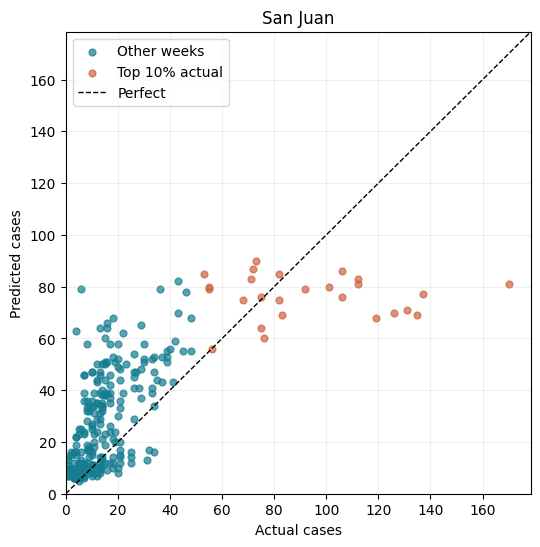

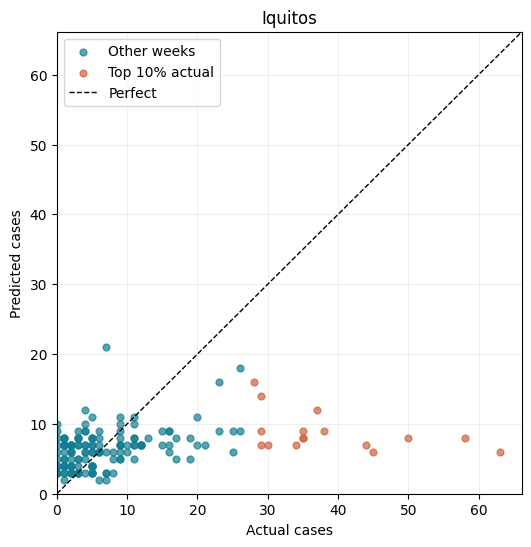

,city,group,weeks,mae
0,sj,Other weeks,234,15.26
1,sj,Top 10% actual,26,27.31
2,iq,Other weeks,140,4.41
3,iq,Top 10% actual,16,29.88


In [12]:
def plot_magnitude(city, prediction_column=PREDICTION):
    df = holdout_for(city)
    threshold = df.actual.quantile(.90)
    high = df.actual.ge(threshold)
    fig, ax = plt.subplots(figsize=(6, 6))
    for mask, label, color in ((~high, "Other weeks", "#147d91"),
                               (high, "Top 10% actual", "#cf613d")):
        ax.scatter(df.loc[mask, "actual"], df.loc[mask, prediction_column],
                   alpha=.7, s=24, label=label, color=color)
    limit = max(df.actual.max(), df[prediction_column].max()) * 1.05
    ax.plot([0, limit], [0, limit], "k--", lw=1, label="Perfect")
    ax.set(xlim=(0, limit), ylim=(0, limit), xlabel="Actual cases",
           ylabel="Predicted cases", title=CITY_NAMES.get(city, city))
    ax.legend()
    ax.grid(alpha=.2)
    plt.show()
    return pd.DataFrame([
        {"city": city, "group": label, "weeks": int(mask.sum()),
         "mae": mean_absolute_error(df.loc[mask, "actual"],
                                    df.loc[mask, prediction_column]) if mask.any() else np.nan}
        for label, mask in (("Other weeks", ~high), ("Top 10% actual", high))
    ])

display(pd.concat([plot_magnitude(city) for city in ("sj", "iq")
                   if city in predictions.city.values], ignore_index=True).round(2))

## MAE by forecast origin

Each bar scores that origin's complete forecast horizon. Earlier origins were used to select the equal-weight ensemble; the final bar is its chronological holdout.

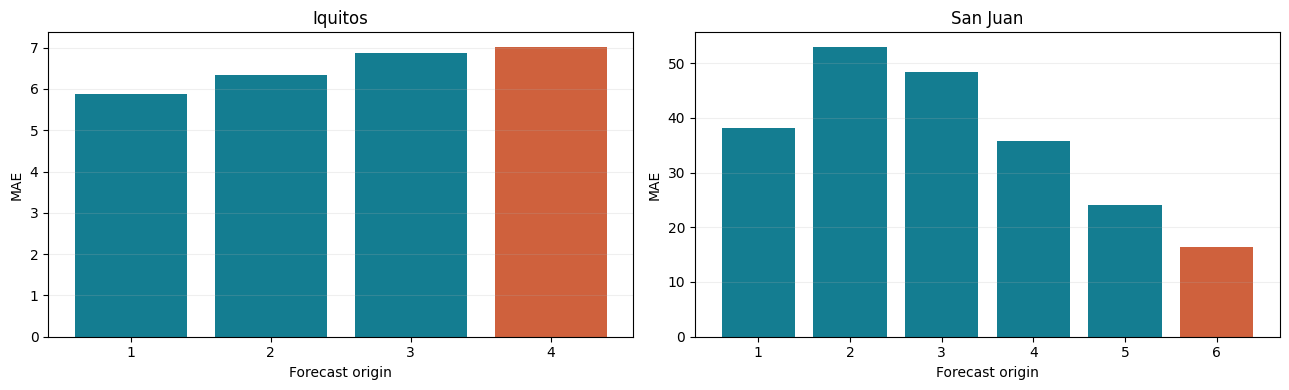

,city,origin,mae
0,iq,1,5.87
1,iq,2,6.35
2,iq,3,6.88
3,iq,4,7.02
4,sj,1,38.07
5,sj,2,52.97
6,sj,3,48.38
7,sj,4,35.73
8,sj,5,24.15
9,sj,6,16.47


In [13]:
origin_mae = (predictions.groupby(["city", "origin"])
              .apply(lambda group: mean_absolute_error(group.actual, group[PREDICTION]),
                     include_groups=False)
              .rename("mae").reset_index())
fig, axes = plt.subplots(1, len(origin_mae.city.unique()), figsize=(13, 4), squeeze=False)
for ax, (city, frame) in zip(axes[0], origin_mae.groupby("city")):
    last_origin = frame.origin.max()
    colors = ["#cf613d" if origin == last_origin else "#147d91" for origin in frame.origin]
    ax.bar(frame.origin.astype(str), frame.mae, color=colors)
    ax.set(xlabel="Forecast origin", ylabel="MAE", title=CITY_NAMES.get(city, city))
    ax.grid(axis="y", alpha=.2)
fig.tight_layout()
plt.show()
display(origin_mae.round(2))

## Selected versus robust on the holdout

Both ensembles are scored on the same held out weeks. Use this plot to inspect differences without refitting models or changing the submission.

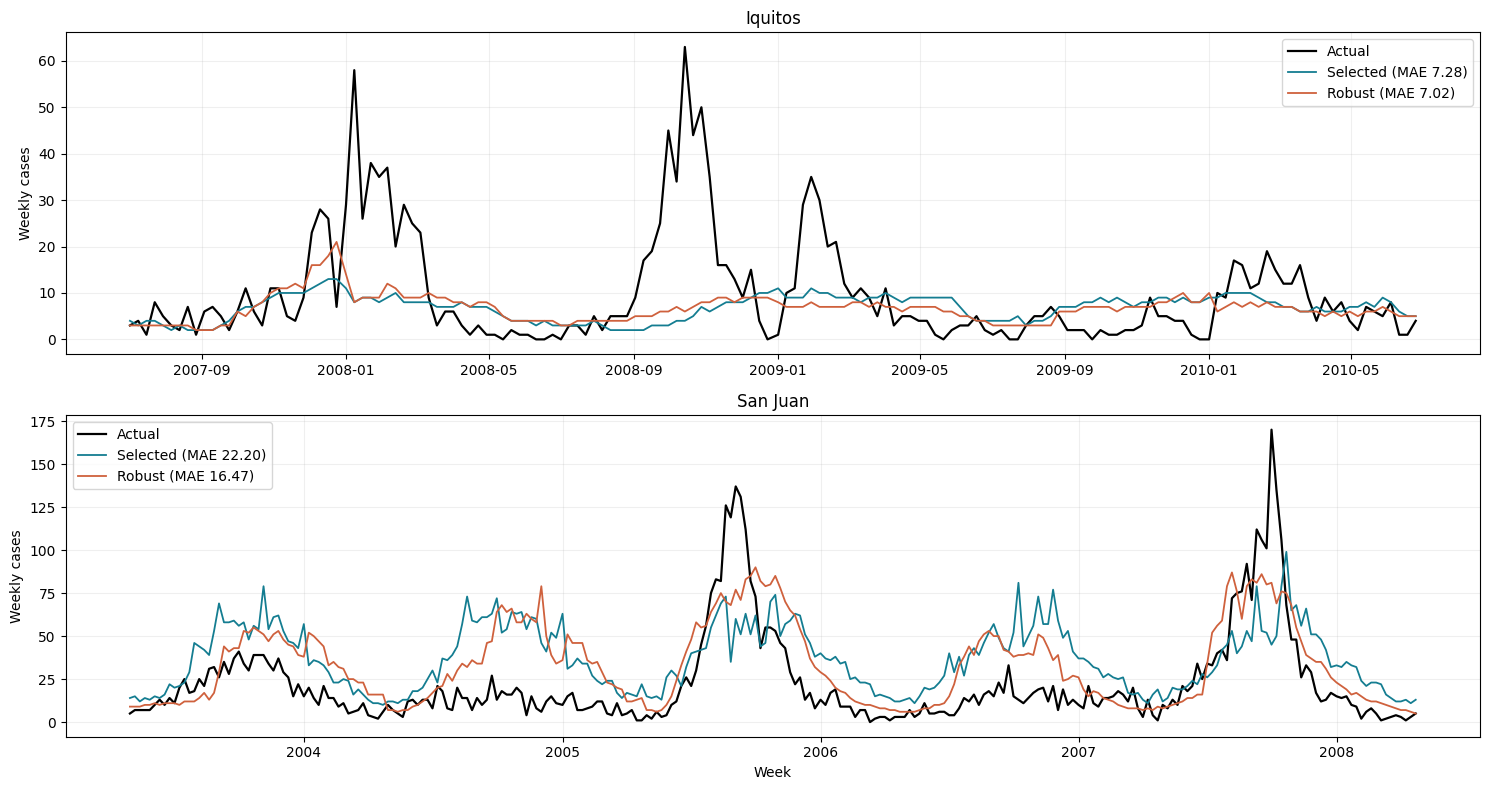

In [14]:
fig, axes = plt.subplots(len(predictions.city.unique()), 1, figsize=(15, 4 * len(predictions.city.unique())), squeeze=False)
for ax, city in zip(axes[:, 0], sorted(predictions.city.unique())):
    df = holdout_for(city)
    ax.plot(df.week_start_date, df.actual, color="black", lw=1.6, label="Actual")
    for column, color, name in (("selected_ensemble_prediction", "#147d91", "Selected"),
                                ("robust_ensemble_prediction", "#cf613d", "Robust")):
        mae = mean_absolute_error(df.actual, df[column])
        ax.plot(df.week_start_date, df[column], color=color, lw=1.3,
                label=f"{name} (MAE {mae:.2f})")
    ax.set(title=CITY_NAMES.get(city, city), ylabel="Weekly cases")
    ax.grid(alpha=.2)
    ax.legend()
axes[-1, 0].set_xlabel("Week")
fig.tight_layout()
plt.show()